### Setup Env

In [1]:
!pip install torchvision

In [2]:
!pip install torchinfo

In [3]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [4]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load the Data

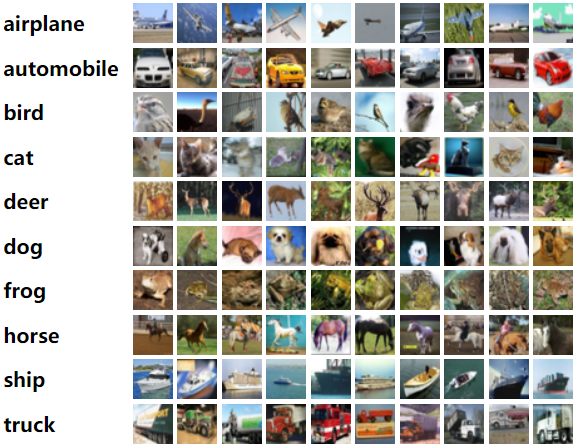

In [5]:
# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1] range
])

In [6]:
# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from PIL import Image

class CustomCIFAR10(Dataset):
    def __init__(self, root, train=True, transform=None):
        """
        Args:
            root (string): Path to the CIFAR-10 data directory
            train (bool): Load training set if True, else test set
            transform (callable): Optional transform to apply to samples
        """
        self.root = root
        self.train = train
        self.transform = transform

        # Load raw data files
        if self.train:
            data_files = [f'data_batch_{i}' for i in range(1,6)]
        else:
            data_files = ['test_batch']

        self.data = []
        self.labels = []

        for file_name in data_files:
            file_path = os.path.join(root, file_name)
            batch_data = self._unpickle(file_path)
            self.data.append(batch_data[b'data'])
            self.labels.extend(batch_data[b'labels'])

        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC format
        self.labels = np.array(self.labels)

    def _unpickle(self, file):
        import pickle
        with open(file, 'rb') as fo:
            dict = pickle.load(fo, encoding='bytes')
        return dict

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]

        # Convert numpy array to PIL Image for transforms
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label


# Create custom dataset
train_dataset = CustomCIFAR10(root='./data/cifar-10-batches-py',
                            train=True,
                            transform=transform)
test_dataset = CustomCIFAR10(root='./data/cifar-10-batches-py',
                           train=False,
                           transform=transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
# Split training set into train and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [10]:
# Create data loaders
batch_size = 128  # We'll experiment with this later

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Check dataset statistics and visualize some samples
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of batches in train loader: {len(train_loader)}")

# Get class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Training samples: 40000
Validation samples: 10000
Test samples: 10000
Batch size: 128
Number of batches in train loader: 313


### Role of Dataset & DataLoader

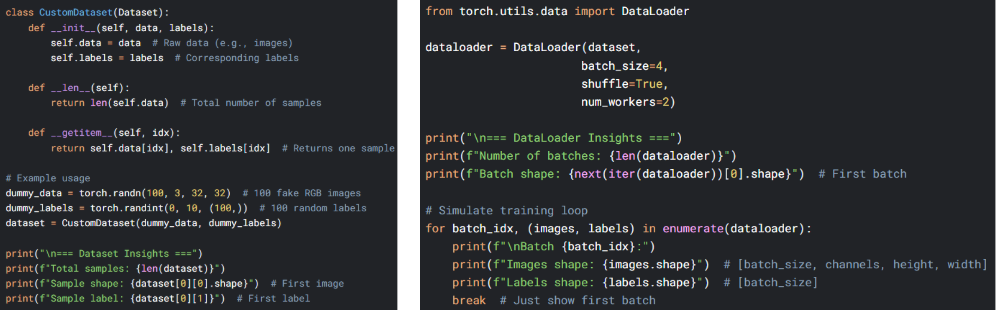

### Visualize Data

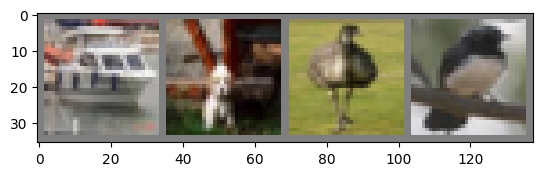

ship  dog   bird  bird 


In [ ]:
# Visualize some training examples
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:4]))
# Print labels
print(' '.join(f'{class_names[labels[j]]:5s}' for j in range(4)))

# Design MLP

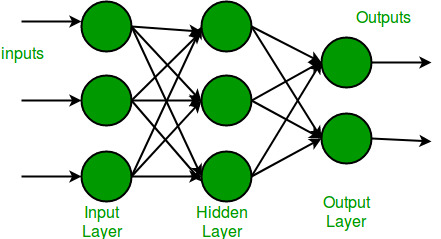

In [15]:
n_in = 3
n_out = 2

Xavier -> Var(W) = 1 / n_in , Var(W) = 2 / (n_in + n_out)

He -> Var(W) = 2/n_in  ,

Distribution -> Normal(0 , Variance) , Uniform(-rad(6/(n_in + n_out)) , rad(6/(n_in + n_out)))


In [ ]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): ReLU()
  (7): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
# Simplified MLP for CIFAR-10 Classification
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()

        # Define the network architecture
        self.flatten = nn.Flatten()  # Flatten 32x32x3 images to 3072-dimensional vectors

        # Hidden layers with ReLU activation
        self.fc1 = nn.Linear(32*32*3, 512)  # Input layer (3072) → 512 neurons
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(512, 256)      # 512 → 256 neurons
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(256, 128)      # 256 → 128 neurons
        self.relu3 = nn.ReLU()

        # Output layer (10 classes for CIFAR-10)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        # Forward pass through the network
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Create an instance of our simple MLP
model = SimpleMLP()
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Print model summary (requires torchinfo)
from torchinfo import summary
summary(model, input_size=(batch_size, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleMLP                                [128, 10]                 --
├─Flatten: 1-1                           [128, 3072]               --
├─Linear: 1-2                            [128, 512]                1,573,376
├─ReLU: 1-3                              [128, 512]                --
├─Linear: 1-4                            [128, 256]                131,328
├─ReLU: 1-5                              [128, 256]                --
├─Linear: 1-6                            [128, 128]                32,896
├─ReLU: 1-7                              [128, 128]                --
├─Linear: 1-8                            [128, 10]                 1,290
Total params: 1,738,890
Trainable params: 1,738,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 222.58
Input size (MB): 1.57
Forward/backward pass size (MB): 0.93
Params size (MB): 6.96
Estimated Total Size (MB): 9.46

# Train MLP

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    # Lists to store metrics
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        # Calculate validation metrics
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        # Print epoch statistics
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

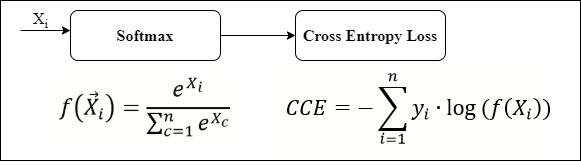

In [ ]:
# Initialize model, loss function, and optimizer
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
trained_model, train_loss, train_acc, val_loss, val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=15
)

Epoch 1/15: Train Loss: 1.6864, Train Acc: 39.80% | Val Loss: 1.5305, Val Acc: 45.72%
Epoch 2/15: Train Loss: 1.4582, Train Acc: 48.30% | Val Loss: 1.4270, Val Acc: 49.65%
Epoch 3/15: Train Loss: 1.3413, Train Acc: 52.38% | Val Loss: 1.4280, Val Acc: 49.95%
Epoch 4/15: Train Loss: 1.2426, Train Acc: 56.13% | Val Loss: 1.3503, Val Acc: 52.72%
Epoch 5/15: Train Loss: 1.1532, Train Acc: 59.15% | Val Loss: 1.3666, Val Acc: 52.52%
Epoch 6/15: Train Loss: 1.0649, Train Acc: 62.30% | Val Loss: 1.3597, Val Acc: 53.09%
Epoch 7/15: Train Loss: 0.9743, Train Acc: 65.22% | Val Loss: 1.3596, Val Acc: 53.82%
Epoch 8/15: Train Loss: 0.8962, Train Acc: 67.92% | Val Loss: 1.4412, Val Acc: 53.31%
Epoch 9/15: Train Loss: 0.8208, Train Acc: 70.69% | Val Loss: 1.4823, Val Acc: 53.82%
Epoch 10/15: Train Loss: 0.7374, Train Acc: 73.50% | Val Loss: 1.6041, Val Acc: 53.38%
Epoch 11/15: Train Loss: 0.6727, Train Acc: 75.84% | Val Loss: 1.6383, Val Acc: 54.11%
Epoch 12/15: Train Loss: 0.6008, Train Acc: 78.42% |

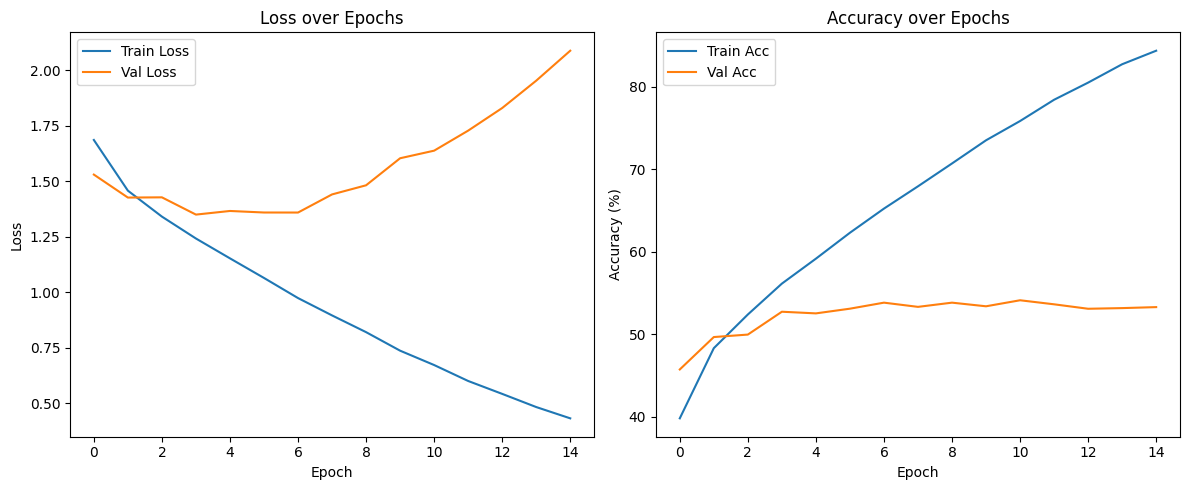

In [ ]:
def plot_taining_history(train_loss_history, train_acc_history, val_loss_history, val_acc_history):
    # Plot training history
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(train_acc_history, label='Train Acc')
    plt.plot(val_acc_history, label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_taining_history(train_loss, train_acc, val_loss, val_acc)

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%')
    return test_acc

# Evaluate the trained model
test_accuracy = evaluate_model(trained_model, test_loader)

Test Loss: 2.0922, Test Accuracy: 52.66%


## Alternative Designs - Overfit/Underfit

In [16]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
trained_model, train_loss, train_acc, val_loss, val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=50
)

Epoch 1/50: Train Loss: 1.6708, Train Acc: 41.15% | Val Loss: 1.5446, Val Acc: 45.65%
Epoch 2/50: Train Loss: 1.4756, Train Acc: 48.47% | Val Loss: 1.4942, Val Acc: 47.34%
Epoch 3/50: Train Loss: 1.3844, Train Acc: 51.88% | Val Loss: 1.4538, Val Acc: 49.73%
Epoch 4/50: Train Loss: 1.3193, Train Acc: 54.22% | Val Loss: 1.4180, Val Acc: 50.22%
Epoch 5/50: Train Loss: 1.2694, Train Acc: 55.82% | Val Loss: 1.4101, Val Acc: 51.18%
Epoch 6/50: Train Loss: 1.2246, Train Acc: 57.39% | Val Loss: 1.4183, Val Acc: 51.52%
Epoch 7/50: Train Loss: 1.1727, Train Acc: 59.49% | Val Loss: 1.4326, Val Acc: 51.29%
Epoch 8/50: Train Loss: 1.1361, Train Acc: 60.64% | Val Loss: 1.4185, Val Acc: 51.86%
Epoch 9/50: Train Loss: 1.1032, Train Acc: 61.83% | Val Loss: 1.4666, Val Acc: 50.64%
Epoch 10/50: Train Loss: 1.0690, Train Acc: 62.98% | Val Loss: 1.4567, Val Acc: 50.71%
Epoch 11/50: Train Loss: 1.0291, Train Acc: 64.25% | Val Loss: 1.4682, Val Acc: 51.08%
Epoch 12/50: Train Loss: 1.0048, Train Acc: 65.30% |

In [ ]:
test_accuracy = model(trained_model, test_loader)

In [14]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
trained_model, train_loss, train_acc, val_loss, val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=15
)

Epoch 1/15: Train Loss: 1.8027, Train Acc: 34.47% | Val Loss: 1.6478, Val Acc: 40.95%
Epoch 2/15: Train Loss: 1.5458, Train Acc: 45.32% | Val Loss: 1.5221, Val Acc: 46.29%
Epoch 3/15: Train Loss: 1.4266, Train Acc: 49.70% | Val Loss: 1.4561, Val Acc: 48.75%
Epoch 4/15: Train Loss: 1.3242, Train Acc: 53.15% | Val Loss: 1.4191, Val Acc: 50.53%
Epoch 5/15: Train Loss: 1.2278, Train Acc: 56.69% | Val Loss: 1.3914, Val Acc: 52.27%
Epoch 6/15: Train Loss: 1.1371, Train Acc: 59.93% | Val Loss: 1.3998, Val Acc: 52.94%
Epoch 7/15: Train Loss: 1.0506, Train Acc: 62.73% | Val Loss: 1.4030, Val Acc: 53.78%
Epoch 8/15: Train Loss: 0.9692, Train Acc: 65.78% | Val Loss: 1.4142, Val Acc: 54.13%
Epoch 9/15: Train Loss: 0.8846, Train Acc: 68.86% | Val Loss: 1.4491, Val Acc: 53.78%
Epoch 10/15: Train Loss: 0.8047, Train Acc: 71.34% | Val Loss: 1.5282, Val Acc: 53.59%
Epoch 11/15: Train Loss: 0.7167, Train Acc: 74.56% | Val Loss: 1.5991, Val Acc: 54.49%
Epoch 12/15: Train Loss: 0.6507, Train Acc: 76.95% |

In [ ]:
test_accuracy = evaluate_model(trained_model, test_loader)

### 🗣 Discuss Early Stopping

# Weight Initialization

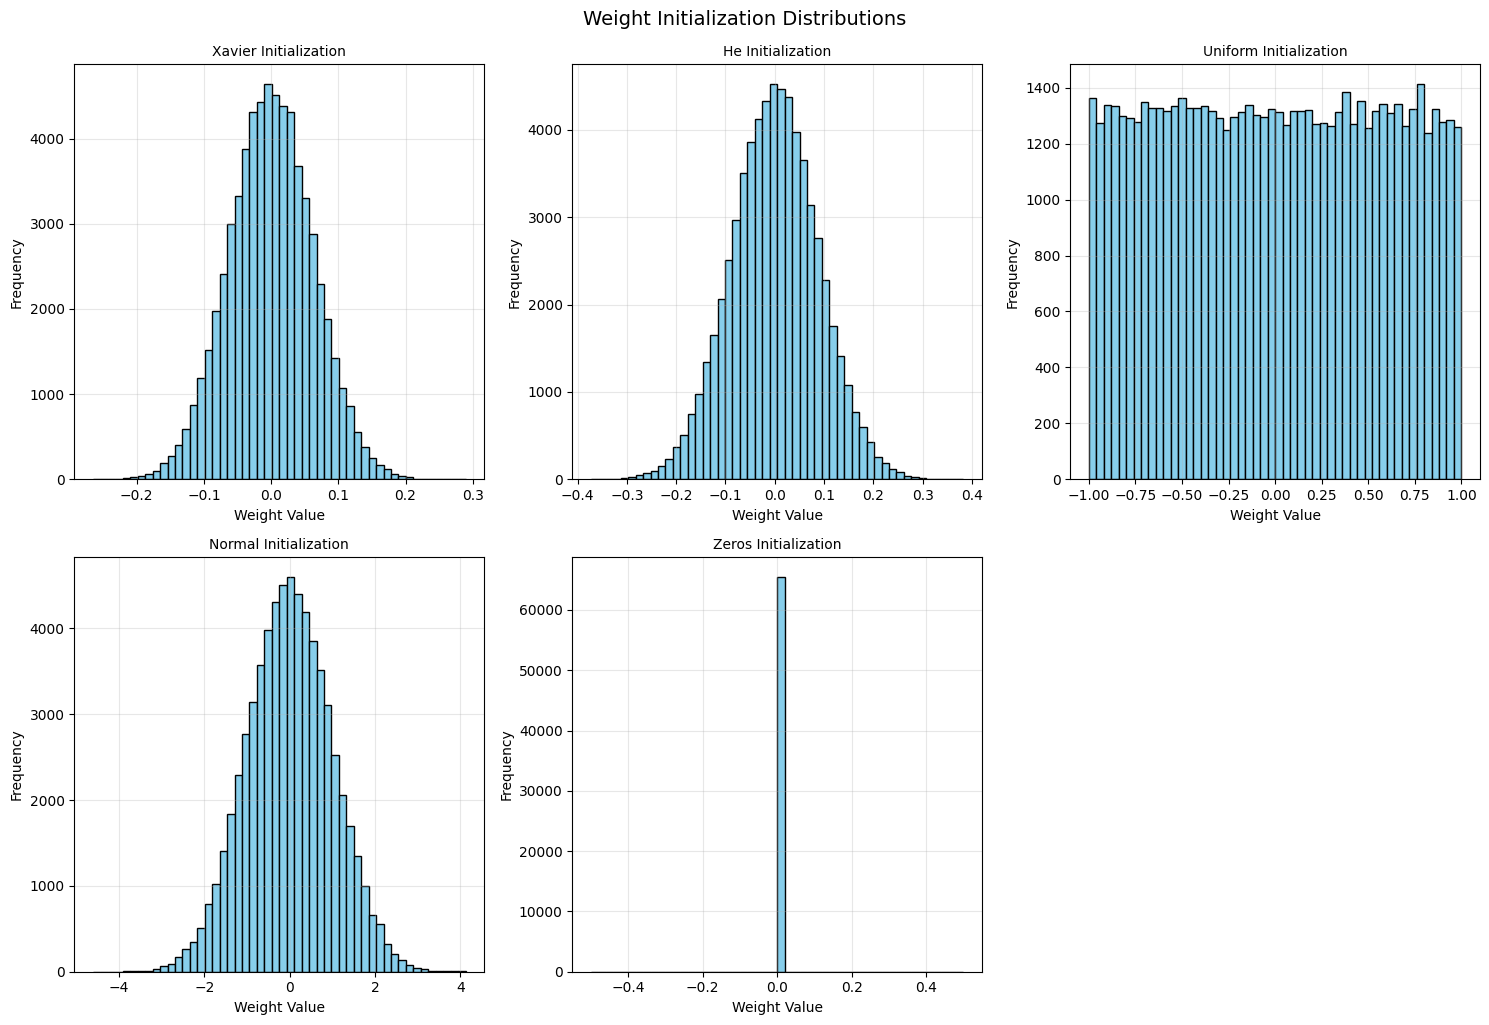

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Define layer sizes
input_size = 256
hidden_size = 256

# Different initialization methods
def init_weights(m, method):
    if isinstance(m, nn.Linear):
        if method == 'xavier':
            nn.init.xavier_normal_(m.weight)
        elif method == 'he':
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        elif method == 'uniform':
            nn.init.uniform_(m.weight, -1, 1)
        elif method == 'normal':
            nn.init.normal_(m.weight, mean=0, std=1)
        elif method == 'zeros':
            nn.init.zeros_(m.weight)

# Create histograms of weights for different initialization methods
methods = ['xavier', 'he', 'uniform', 'normal', 'zeros']
plt.figure(figsize=(15, 10))

for i, method in enumerate(methods):
    # Create a linear layer
    layer = nn.Linear(input_size, hidden_size)
    # Apply initialization
    init_weights(layer, method)

    # Get weights and flatten
    weights = layer.weight.data.numpy().flatten()

    # Plot histogram
    plt.subplot(2, 3, i+1)
    plt.hist(weights, bins=50, color='skyblue', edgecolor='black')
    plt.title(f'{method.capitalize()} Initialization', fontsize=10)
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Weight Initialization Distributions', y=1.02, fontsize=14)
plt.show()

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, init_method=None):  # None means use PyTorch default
        super(SimpleMLP, self).__init__()
        self.init_method = init_method

        # Network architecture (same as before)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(128, 10)

        # Only initialize if method specified
        if init_method:
            self._initialize_weights()

    def _initialize_weights(self):
        init_funcs = {
            'xavier': nn.init.xavier_normal_,
            'he': nn.init.kaiming_normal_,
            'uniform': lambda w: nn.init.uniform_(w, -0.1, 0.1),
            'zeros': nn.init.zeros_
        }

        init_func = init_funcs[self.init_method]

        for m in self.modules():
            if isinstance(m, nn.Linear):
                init_func(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Unchanged forward pass
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

In [ ]:
# Quick weight distribution check
def show_weight_distribution(model, title):
    weights = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            weights.extend(param.data.flatten().numpy())

    plt.figure(figsize=(8, 4))
    plt.hist(weights, bins=50, alpha=0.7)
    plt.title(f"Weight Distribution ({title} Init)")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.show()

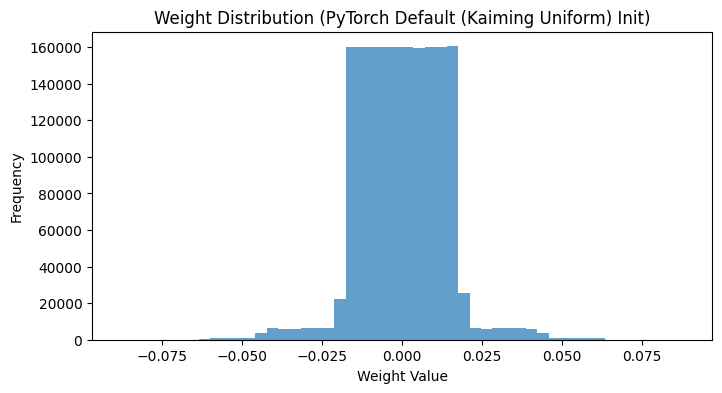

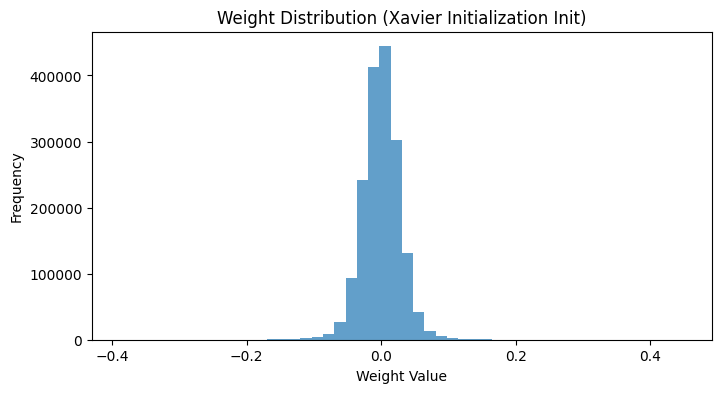

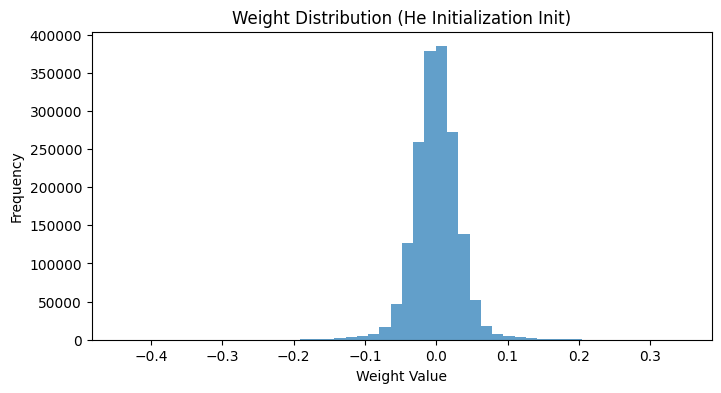

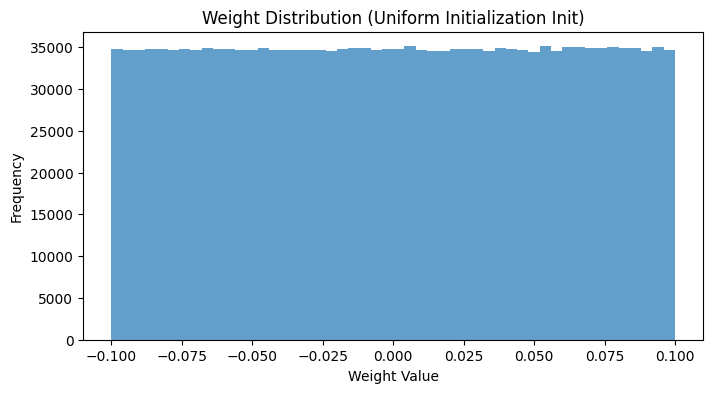

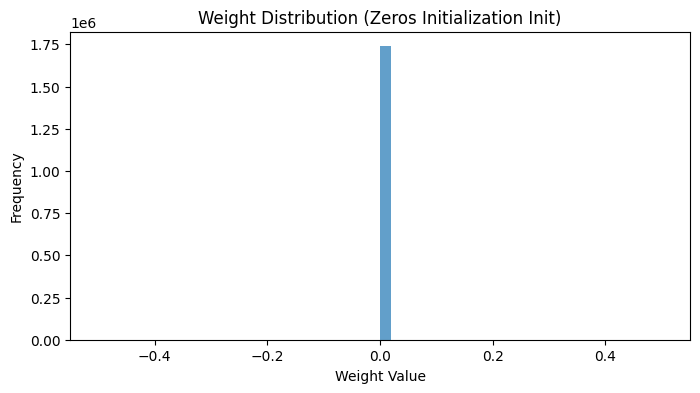

In [ ]:
# 1. Show default initialization weights
default_model = SimpleMLP()  # No init_method specified
show_weight_distribution(default_model, "PyTorch Default (Kaiming Uniform)")

# 2. Compare with other methods
methods = ['xavier', 'he', 'uniform', 'zeros']

for method in methods:
    model = SimpleMLP(init_method=method)
    show_weight_distribution(model, f"{method.capitalize()} Initialization")


Training with he initialization...
Epoch 1/10: Train Loss: 1.7319, Train Acc: 39.26% | Val Loss: 1.5738, Val Acc: 44.30%
Epoch 2/10: Train Loss: 1.4997, Train Acc: 47.03% | Val Loss: 1.5266, Val Acc: 47.50%
Epoch 3/10: Train Loss: 1.3815, Train Acc: 51.22% | Val Loss: 1.4546, Val Acc: 49.51%
Epoch 4/10: Train Loss: 1.2854, Train Acc: 54.80% | Val Loss: 1.4278, Val Acc: 50.22%
Epoch 5/10: Train Loss: 1.2080, Train Acc: 57.35% | Val Loss: 1.4187, Val Acc: 50.51%
Epoch 6/10: Train Loss: 1.1295, Train Acc: 60.38% | Val Loss: 1.4460, Val Acc: 50.29%
Epoch 7/10: Train Loss: 1.0514, Train Acc: 62.87% | Val Loss: 1.4259, Val Acc: 51.81%
Epoch 8/10: Train Loss: 0.9747, Train Acc: 65.70% | Val Loss: 1.4386, Val Acc: 51.59%
Epoch 9/10: Train Loss: 0.9046, Train Acc: 68.03% | Val Loss: 1.5200, Val Acc: 51.29%
Epoch 10/10: Train Loss: 0.8311, Train Acc: 70.73% | Val Loss: 1.5591, Val Acc: 51.54%

Training with xavier initialization...
Epoch 1/10: Train Loss: 1.6989, Train Acc: 40.09% | Val Loss: 1

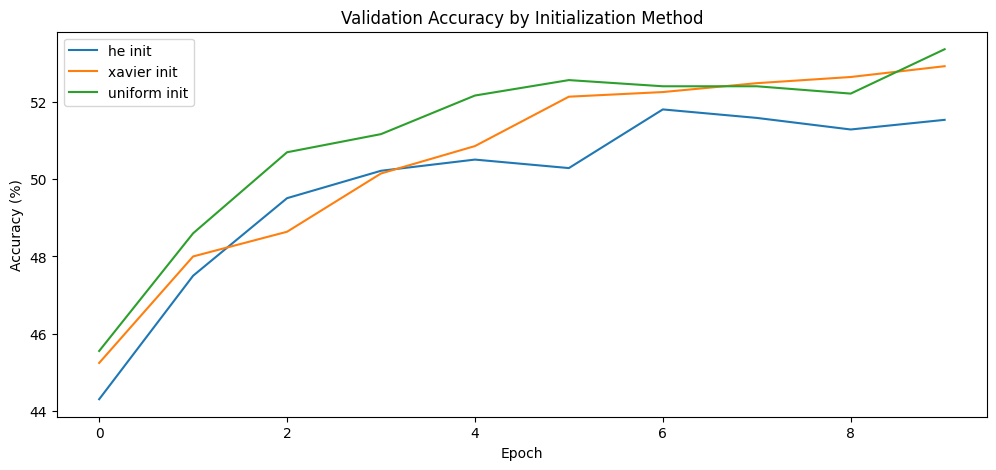

In [ ]:
# Compare initialization methods through training
init_methods = ['he', 'xavier', 'uniform']
results = {}

for method in init_methods:
    print(f"\nTraining with {method} initialization...")
    model = SimpleMLP(init_method=method)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    _, train_loss, train_acc, val_loss, val_acc = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=nn.CrossEntropyLoss(),
        optimizer=optimizer,
        num_epochs=10
    )

    results[method] = {
        'train_loss': train_loss,
        'val_acc': val_acc
    }

# Plot comparison
plt.figure(figsize=(12, 5))
for method, data in results.items():
    plt.plot(data['val_acc'], label=f'{method} init')
plt.title('Validation Accuracy by Initialization Method')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Activation Fucntions

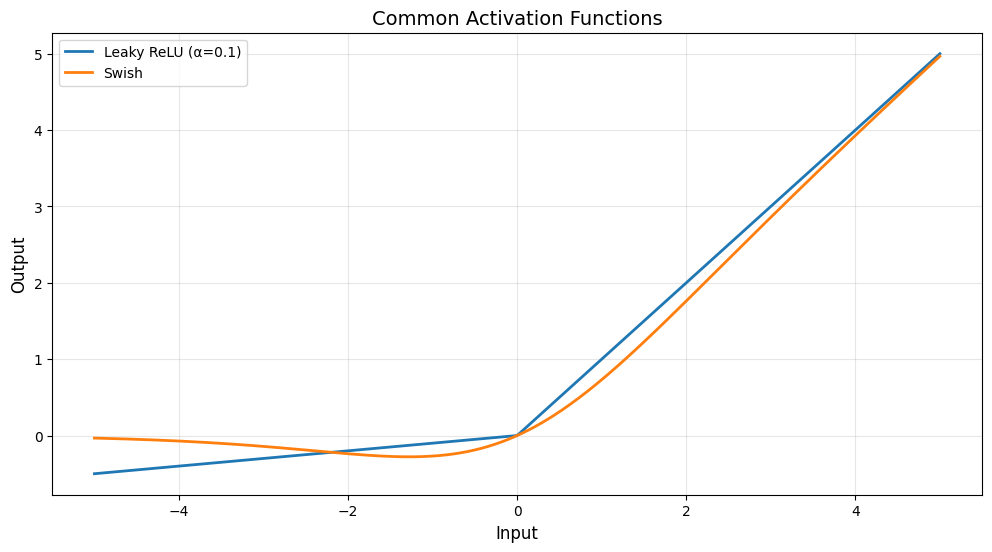

In [18]:
# Define common activation functions
def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def swish(x):
    return x * sigmoid(x)

# Create a range of values
x = np.linspace(-5, 5, 500)

# Plot activation functions
plt.figure(figsize=(12, 6))

# plt.plot(x, relu(x), label='ReLU', linewidth=2)
# plt.plot(x, tanh(x), label='Tanh', linewidth=2)
# plt.plot(x, sigmoid(x), label='Sigmoid', linewidth=2)
plt.plot(x, leaky_relu(x), label='Leaky ReLU (α=0.1)', linewidth=2)
plt.plot(x, swish(x), label='Swish', linewidth=2)

plt.title('Common Activation Functions', fontsize=14)
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()

In [ ]:
class ActivationMLP(nn.Module):
    def __init__(self, activation='relu'):
        super(ActivationMLP, self).__init__()

        # Activation selection
        self.activation = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'swish': nn.SiLU(),
            'gelu': nn.GELU()
        }[activation]

        # Architecture
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 512),
            self.activation,
            nn.Linear(512, 256),
            self.activation,
            nn.Linear(256, 128),
            self.activation,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


=== Training with RELU activation ===
Epoch 1/10: Train Loss: 1.6830, Train Acc: 40.00% | Val Loss: 1.5535, Val Acc: 44.80%
Epoch 2/10: Train Loss: 1.4654, Train Acc: 48.00% | Val Loss: 1.4520, Val Acc: 49.49%
Epoch 3/10: Train Loss: 1.3389, Train Acc: 52.71% | Val Loss: 1.3907, Val Acc: 51.18%
Epoch 4/10: Train Loss: 1.2426, Train Acc: 55.81% | Val Loss: 1.3799, Val Acc: 51.63%
Epoch 5/10: Train Loss: 1.1481, Train Acc: 59.48% | Val Loss: 1.4330, Val Acc: 50.95%
Epoch 6/10: Train Loss: 1.0666, Train Acc: 62.06% | Val Loss: 1.3611, Val Acc: 53.89%
Epoch 7/10: Train Loss: 0.9811, Train Acc: 65.05% | Val Loss: 1.4261, Val Acc: 52.39%
Epoch 8/10: Train Loss: 0.8988, Train Acc: 68.02% | Val Loss: 1.4465, Val Acc: 53.60%
Epoch 9/10: Train Loss: 0.8191, Train Acc: 70.90% | Val Loss: 1.4852, Val Acc: 53.26%
Epoch 10/10: Train Loss: 0.7396, Train Acc: 73.30% | Val Loss: 1.5088, Val Acc: 54.15%

=== Training with LEAKY_RELU activation ===
Epoch 1/10: Train Loss: 1.6941, Train Acc: 39.63% | Val

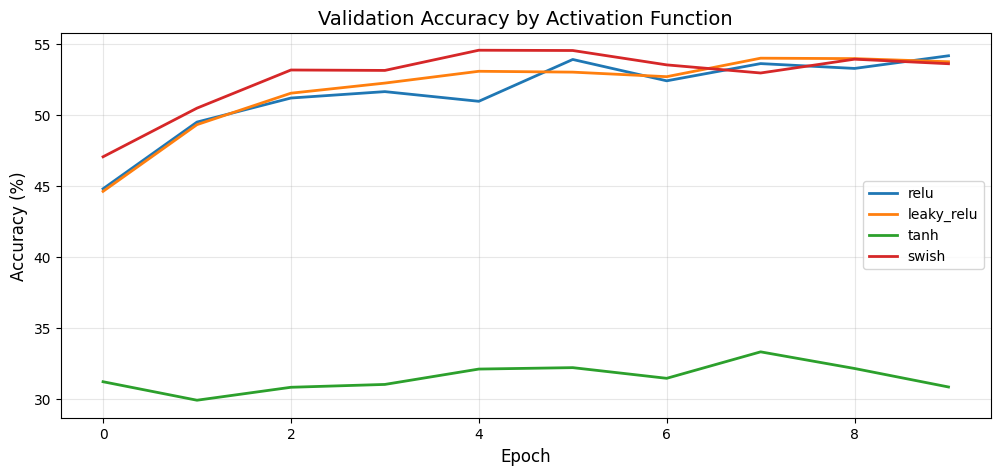

In [ ]:
def compare_activations(activations=['relu', 'leaky_relu', 'tanh', 'swish'], num_epochs=10):
    results = {}

    for act in activations:
        print(f"\n=== Training with {act.upper()} activation ===")
        # model = ActivationMLP(activation=act).to(device)
        model = ActivationMLP(activation=act)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Adjust learning rate for sigmoid/tanh
        if act in ['sigmoid', 'tanh']:
            for g in optimizer.param_groups:
                g['lr'] = 0.01  # Higher LR helps with saturation

        _, train_loss, _, _, val_acc = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=nn.CrossEntropyLoss(),
            optimizer=optimizer,
            num_epochs=num_epochs
        )

        results[act] = {
            'train_loss': train_loss,
            'val_acc': val_acc
        }

    # Plot results
    plt.figure(figsize=(12, 5))
    for act, data in results.items():
        plt.plot(data['val_acc'], label=f'{act}', lw=2)

    plt.title("Validation Accuracy by Activation Function", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results

# Run comparison
activation_results = compare_activations()

# Choice of Loss Function

In [ ]:

# 2. Training with MSE Loss
def train_with_mse():
    model = SimpleMLP()

    # Key difference: MSE requires one-hot encoded labels
    def to_onehot(y, num_classes=10):
        return torch.eye(num_classes)[y]

    criterion = nn.MSELoss()  # MSE instead of CrossEntropy
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("=== Training with MSE Loss ===")
    train_loss_history = []

    for epoch in range(10):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs, labels
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, to_onehot(labels))  # MSE needs one-hot
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_loss_history.append(epoch_loss)
        print(f'Epoch {epoch+1}: Loss = {epoch_loss:.4f}')

    # Plot MSE training
    plt.figure(figsize=(6, 4))
    plt.plot(train_loss_history)
    plt.title("Training with MSE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.show()

    return model

In [ ]:
# 3. Compare with Cross-Entropy (standard)
def train_with_ce():
    model = SimpleMLP()
    criterion = nn.CrossEntropyLoss()  # Standard classification loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("\n=== Training with Cross-Entropy Loss ===")
    train_loss_history = []

    for epoch in range(10):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs, labels
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)  # Direct class indices
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_loss_history.append(epoch_loss)
        print(f'Epoch {epoch+1}: Loss = {epoch_loss:.4f}')

    # Plot CE training
    plt.figure(figsize=(6, 4))
    plt.plot(train_loss_history)
    plt.title("Training with Cross-Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("CE Loss")
    plt.grid(True)
    plt.show()

    return model

In [ ]:
# 4. Performance Comparison
def evaluate(model, name):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs, labels
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"{name} Test Accuracy: {acc:.2f}%")

=== Training with MSE Loss ===
Epoch 1: Loss = 0.0751
Epoch 2: Loss = 0.0675
Epoch 3: Loss = 0.0632
Epoch 4: Loss = 0.0599
Epoch 5: Loss = 0.0566
Epoch 6: Loss = 0.0538
Epoch 7: Loss = 0.0512
Epoch 8: Loss = 0.0481
Epoch 9: Loss = 0.0455
Epoch 10: Loss = 0.0432


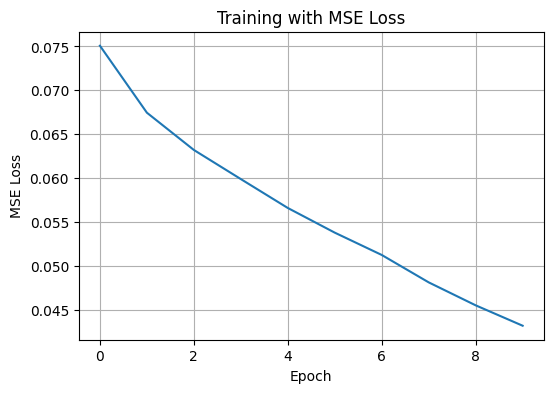


=== Training with Cross-Entropy Loss ===
Epoch 1: Loss = 1.6799
Epoch 2: Loss = 1.4633
Epoch 3: Loss = 1.3393
Epoch 4: Loss = 1.2442
Epoch 5: Loss = 1.1516
Epoch 6: Loss = 1.0669
Epoch 7: Loss = 0.9855
Epoch 8: Loss = 0.9092
Epoch 9: Loss = 0.8187
Epoch 10: Loss = 0.7447


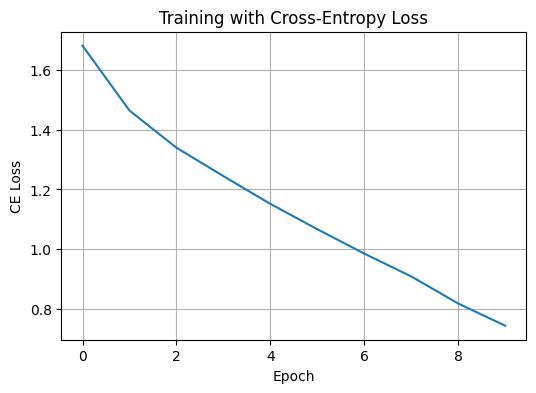

Deeper MSE Test Accuracy: 52.57%
Deeper CE Test Accuracy: 53.23%


In [ ]:
class DeeperMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# Train deeper models
model = DeeperMLP()
deeper_mse = train_with_mse()

model = DeeperMLP()
deeper_ce = train_with_ce()

evaluate(deeper_mse, "Deeper MSE")
evaluate(deeper_ce, "Deeper CE")

### 🗣 Discuss CE vs MSE for this problem

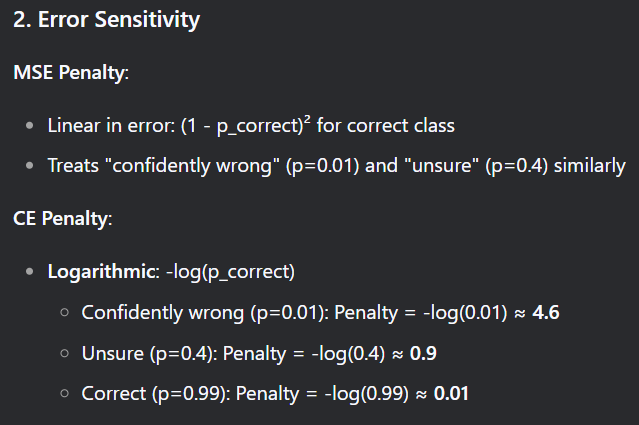

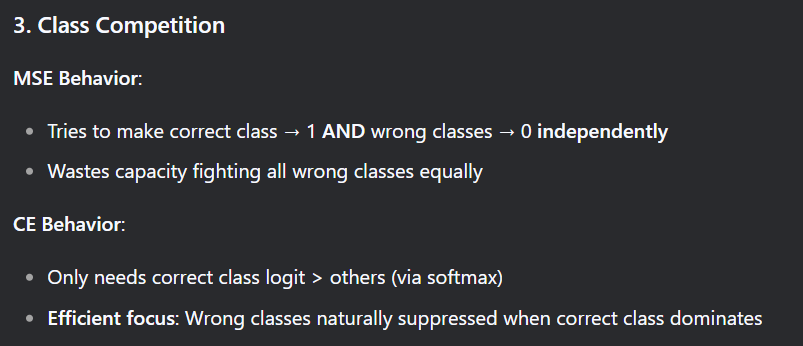

# Optimizer


=== Training with SGD ===

=== Training with Adam ===


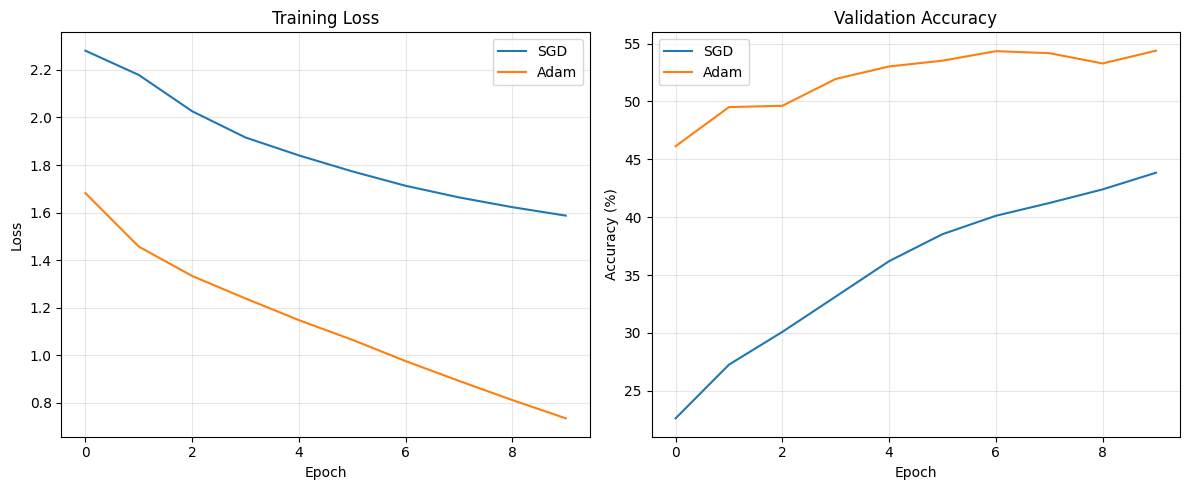

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

def train_with_optimizer(optimizer_name, model, train_loader, val_loader, num_epochs=10):
    # Define optimizer
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        raise ValueError("Unknown optimizer")

    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs, labels
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs, labels
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accs.append(100 * correct / total)

    return train_losses, val_accs

# Compare optimizers
optimizers = ["SGD", "Adam"]
results = {}

for opt_name in optimizers:
    print(f"\n=== Training with {opt_name} ===")
    model = SimpleMLP()
    train_loss, val_acc = train_with_optimizer(opt_name, model, train_loader, val_loader)
    results[opt_name] = {"train_loss": train_loss, "val_acc": val_acc}

# Plot results
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
for opt_name, data in results.items():
    plt.plot(data["train_loss"], label=opt_name)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Validation Accuracy
plt.subplot(1, 2, 2)
for opt_name, data in results.items():
    plt.plot(data["val_acc"], label=opt_name)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Training SGD ===
SGD | Epoch 1/15 | Loss: 1.7877 | Val Acc: 39.97%
SGD | Epoch 2/15 | Loss: 1.5804 | Val Acc: 44.94%
SGD | Epoch 3/15 | Loss: 1.4999 | Val Acc: 46.93%
SGD | Epoch 4/15 | Loss: 1.4643 | Val Acc: 45.84%
SGD | Epoch 5/15 | Loss: 1.4410 | Val Acc: 45.92%
SGD | Epoch 6/15 | Loss: 1.4059 | Val Acc: 47.71%
SGD | Epoch 7/15 | Loss: 1.3663 | Val Acc: 47.78%
SGD | Epoch 8/15 | Loss: 1.3720 | Val Acc: 46.87%
SGD | Epoch 9/15 | Loss: 1.3506 | Val Acc: 47.30%
SGD | Epoch 10/15 | Loss: 1.3183 | Val Acc: 47.99%
SGD | Epoch 11/15 | Loss: 1.2940 | Val Acc: 47.52%
SGD | Epoch 12/15 | Loss: 1.3010 | Val Acc: 45.41%
SGD | Epoch 13/15 | Loss: 1.2645 | Val Acc: 47.01%
SGD | Epoch 14/15 | Loss: 1.2601 | Val Acc: 45.32%
SGD | Epoch 15/15 | Loss: 1.2708 | Val Acc: 47.08%

=== Training Adam ===
Adam | Epoch 1/15 | Loss: 1.6814 | Val Acc: 46.48%
Adam | Epoch 2/15 | Loss: 1.4571 | Val Acc: 49.13%
Adam | Epoch 3/15 | Loss: 1.3316 | Val Acc: 52.14%
Adam | Epoch 4/15 | Loss: 1.2367 | Val Acc: 52.

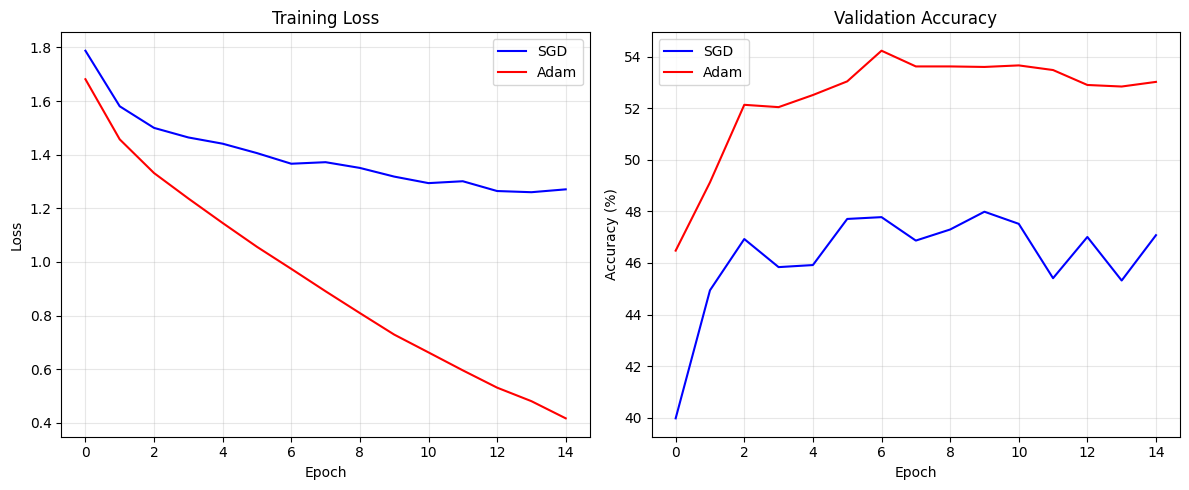

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

def train_simple(model, optimizer, train_loader, val_loader, num_epochs=15, optimizer_name="Optimizer"):
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs, labels
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs, labels
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_accs.append(100 * correct / total)

        print(f"{optimizer_name} | Epoch {epoch+1}/{num_epochs} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

    return train_losses, val_accs

# Initialize models
model_sgd = SimpleMLP()
model_adam = SimpleMLP()

# Optimizers (no schedulers!)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.1, momentum=0.9)  # Classic SGD + Momentum
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)           # Default Adam

# Training
print("=== Training SGD ===")
sgd_loss, sgd_acc = train_simple(model_sgd, optimizer_sgd, train_loader, val_loader, optimizer_name="SGD")

print("\n=== Training Adam ===")
adam_loss, adam_acc = train_simple(model_adam, optimizer_adam, train_loader, val_loader, optimizer_name="Adam")

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sgd_loss, label='SGD', color='blue')
plt.plot(adam_loss, label='Adam', color='red')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sgd_acc, label='SGD', color='blue')
plt.plot(adam_acc, label='Adam', color='red')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scheduler

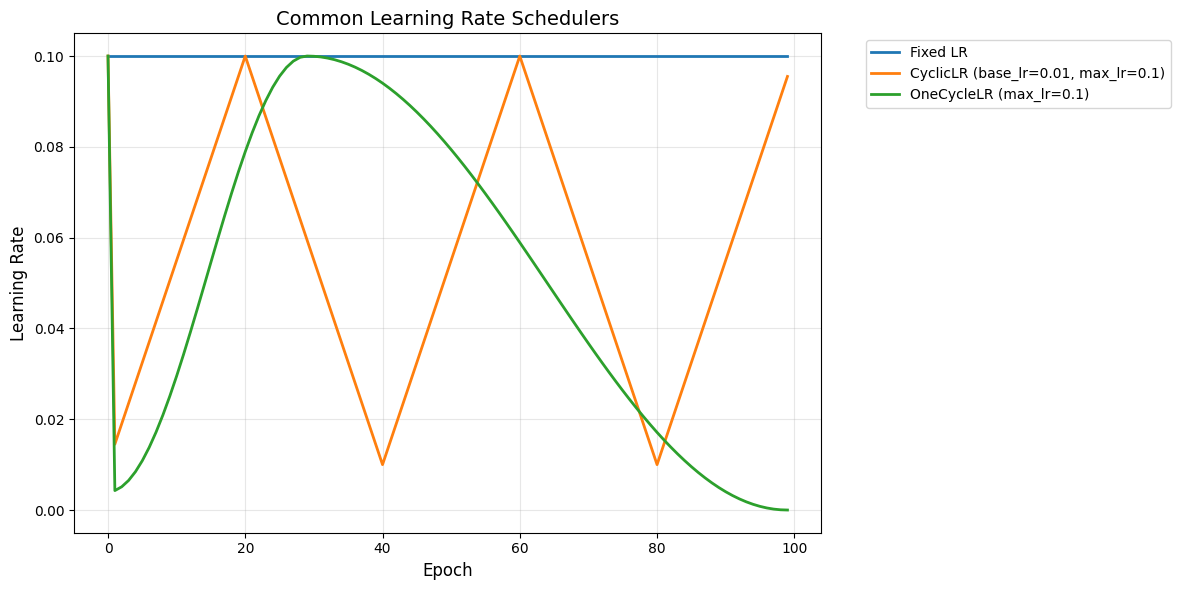

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import (StepLR, MultiStepLR, ExponentialLR,
                                     CosineAnnealingLR, ReduceLROnPlateau,
                                     CyclicLR, OneCycleLR)
import matplotlib.pyplot as plt

# Mock optimizer
model = SimpleMLP()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Simulate 100 epochs
epochs = 100
lr_history = {}

# Define schedulers
schedulers = {
    "Fixed LR": None,
    # "StepLR (step_size=30, gamma=0.1)": StepLR(optimizer, step_size=30, gamma=0.1),
    # "MultiStepLR (milestones=[30,80], gamma=0.1)": MultiStepLR(optimizer, milestones=[30,80], gamma=0.1),
    # "ExponentialLR (gamma=0.95)": ExponentialLR(optimizer, gamma=0.95),
    # "CosineAnnealingLR (T_max=50)": CosineAnnealingLR(optimizer, T_max=50),
    "CyclicLR (base_lr=0.01, max_lr=0.1)": CyclicLR(optimizer, base_lr=0.01, max_lr=0.1, step_size_up=20),
    "OneCycleLR (max_lr=0.1)": OneCycleLR(optimizer, max_lr=0.1, total_steps=epochs)
}

# Simulate LR changes
for name, scheduler in schedulers.items():
    optimizer.param_groups[0]['lr'] = 0.1  # Reset LR
    lr_history[name] = []
    for epoch in range(epochs): 
        lr_history[name].append(optimizer.param_groups[0]['lr'])
        if scheduler:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(loss=0.05)  # Mock loss
            else:
                scheduler.step()

# Plot
plt.figure(figsize=(12, 6))
for name, lrs in lr_history.items():
    plt.plot(lrs, label=name, linewidth=2)

plt.title("Common Learning Rate Schedulers", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Regularization

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Train base model
base_model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(base_model.parameters(), lr=0.001)
_, base_train_loss_history, base_train_acc_history, base_val_loss_history, base_val_acc_history = train_model(base_model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Epoch 1/15: Train Loss: 1.6784, Train Acc: 40.21% | Val Loss: 1.5574, Val Acc: 44.04%
Epoch 2/15: Train Loss: 1.4485, Train Acc: 48.72% | Val Loss: 1.4701, Val Acc: 48.40%
Epoch 3/15: Train Loss: 1.3268, Train Acc: 53.14% | Val Loss: 1.4247, Val Acc: 50.30%
Epoch 4/15: Train Loss: 1.2288, Train Acc: 56.51% | Val Loss: 1.3908, Val Acc: 51.62%
Epoch 5/15: Train Loss: 1.1336, Train Acc: 59.81% | Val Loss: 1.4193, Val Acc: 51.00%
Epoch 6/15: Train Loss: 1.0520, Train Acc: 62.61% | Val Loss: 1.4145, Val Acc: 52.48%
Epoch 7/15: Train Loss: 0.9634, Train Acc: 65.52% | Val Loss: 1.4647, Val Acc: 51.44%
Epoch 8/15: Train Loss: 0.8854, Train Acc: 68.31% | Val Loss: 1.4489, Val Acc: 53.34%
Epoch 9/15: Train Loss: 0.7976, Train Acc: 71.38% | Val Loss: 1.5803, Val Acc: 52.10%
Epoch 10/15: Train Loss: 0.7243, Train Acc: 73.82% | Val Loss: 1.6148, Val Acc: 51.83%
Epoch 11/15: Train Loss: 0.6534, Train Acc: 76.50% | Val Loss: 1.7209, Val Acc: 52.34%
Epoch 12/15: Train Loss: 0.5826, Train Acc: 78.98% |

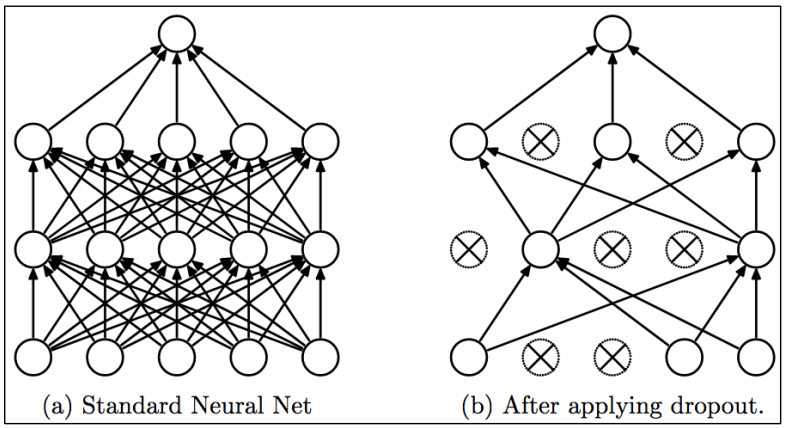

In [ ]:
class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super(DropoutMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.drop1 = nn.Dropout(p)
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.drop2 = nn.Dropout(p)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop1(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.drop2(x)
        x = self.fc4(x)
        return x

# Train dropout model
dropout_model = DropoutMLP(p=0.2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)
_, dropout_train_loss_history, dropout_train_acc_history, dropout_val_loss_history, dropout_val_acc_history = train_model(dropout_model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Epoch 1/15: Train Loss: 1.7424, Train Acc: 37.87% | Val Loss: 1.5600, Val Acc: 44.95%
Epoch 2/15: Train Loss: 1.5351, Train Acc: 45.88% | Val Loss: 1.4524, Val Acc: 49.38%
Epoch 3/15: Train Loss: 1.4292, Train Acc: 49.69% | Val Loss: 1.4238, Val Acc: 50.26%
Epoch 4/15: Train Loss: 1.3440, Train Acc: 52.28% | Val Loss: 1.4209, Val Acc: 51.66%
Epoch 5/15: Train Loss: 1.2689, Train Acc: 54.99% | Val Loss: 1.3833, Val Acc: 52.20%
Epoch 6/15: Train Loss: 1.2041, Train Acc: 57.03% | Val Loss: 1.3511, Val Acc: 52.86%
Epoch 7/15: Train Loss: 1.1438, Train Acc: 59.52% | Val Loss: 1.3767, Val Acc: 52.99%
Epoch 8/15: Train Loss: 1.0866, Train Acc: 61.16% | Val Loss: 1.3337, Val Acc: 54.98%
Epoch 9/15: Train Loss: 1.0252, Train Acc: 63.24% | Val Loss: 1.3658, Val Acc: 53.84%
Epoch 10/15: Train Loss: 0.9709, Train Acc: 64.95% | Val Loss: 1.4110, Val Acc: 53.98%
Epoch 11/15: Train Loss: 0.9211, Train Acc: 66.62% | Val Loss: 1.4258, Val Acc: 54.09%
Epoch 12/15: Train Loss: 0.8717, Train Acc: 68.47% |

In [ ]:
# Same as base model but with weight decay
l2_model = SimpleMLP()
optimizer = optim.Adam(l2_model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 penalty
_, l2_train_loss_history, l2_train_acc_history, l2_val_loss_history, l2_val_acc_history = train_model(l2_model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Epoch 1/15: Train Loss: 1.6835, Train Acc: 40.06% | Val Loss: 1.5235, Val Acc: 46.38%
Epoch 2/15: Train Loss: 1.4701, Train Acc: 47.69% | Val Loss: 1.4342, Val Acc: 49.57%
Epoch 3/15: Train Loss: 1.3588, Train Acc: 51.83% | Val Loss: 1.3839, Val Acc: 51.45%
Epoch 4/15: Train Loss: 1.2693, Train Acc: 55.06% | Val Loss: 1.3625, Val Acc: 52.69%
Epoch 5/15: Train Loss: 1.1945, Train Acc: 57.67% | Val Loss: 1.3756, Val Acc: 51.55%
Epoch 6/15: Train Loss: 1.1250, Train Acc: 59.88% | Val Loss: 1.3547, Val Acc: 53.25%
Epoch 7/15: Train Loss: 1.0591, Train Acc: 62.30% | Val Loss: 1.3721, Val Acc: 52.91%
Epoch 8/15: Train Loss: 0.9970, Train Acc: 64.53% | Val Loss: 1.4078, Val Acc: 53.50%
Epoch 9/15: Train Loss: 0.9336, Train Acc: 66.75% | Val Loss: 1.4433, Val Acc: 53.43%
Epoch 10/15: Train Loss: 0.8730, Train Acc: 68.64% | Val Loss: 1.4403, Val Acc: 53.76%
Epoch 11/15: Train Loss: 0.8232, Train Acc: 70.31% | Val Loss: 1.4588, Val Acc: 52.83%
Epoch 12/15: Train Loss: 0.7607, Train Acc: 72.70% |

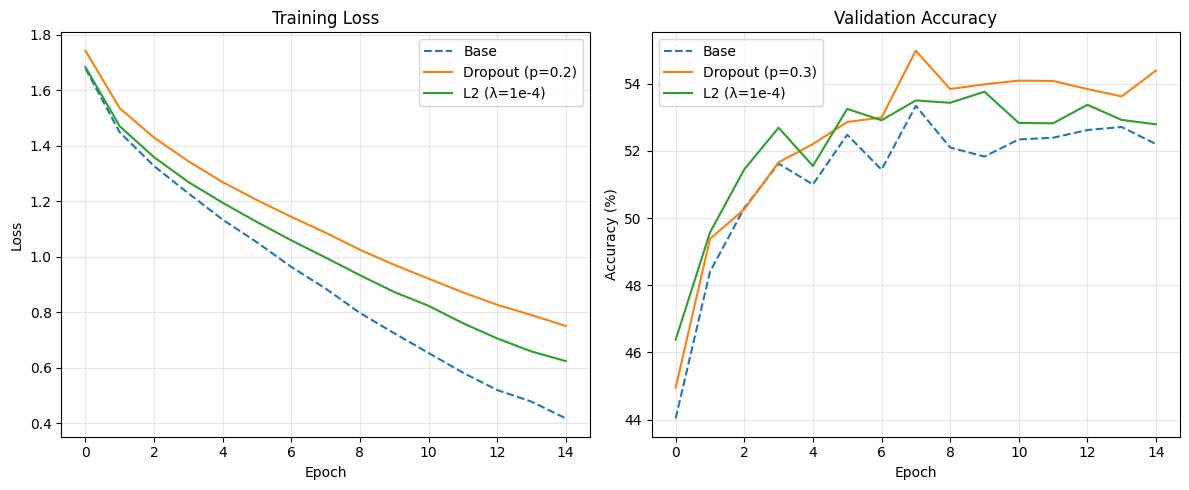

In [ ]:
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(base_train_loss_history, label='Base', linestyle='--')
plt.plot(dropout_train_loss_history, label='Dropout (p=0.2)')
plt.plot(l2_train_loss_history, label='L2 (λ=1e-4)')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(base_val_acc_history, label='Base', linestyle='--')
plt.plot(dropout_val_acc_history, label='Drop  out (p=0.3)')
plt.plot(l2_val_acc_history, label='L2 (λ=1e-4)')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

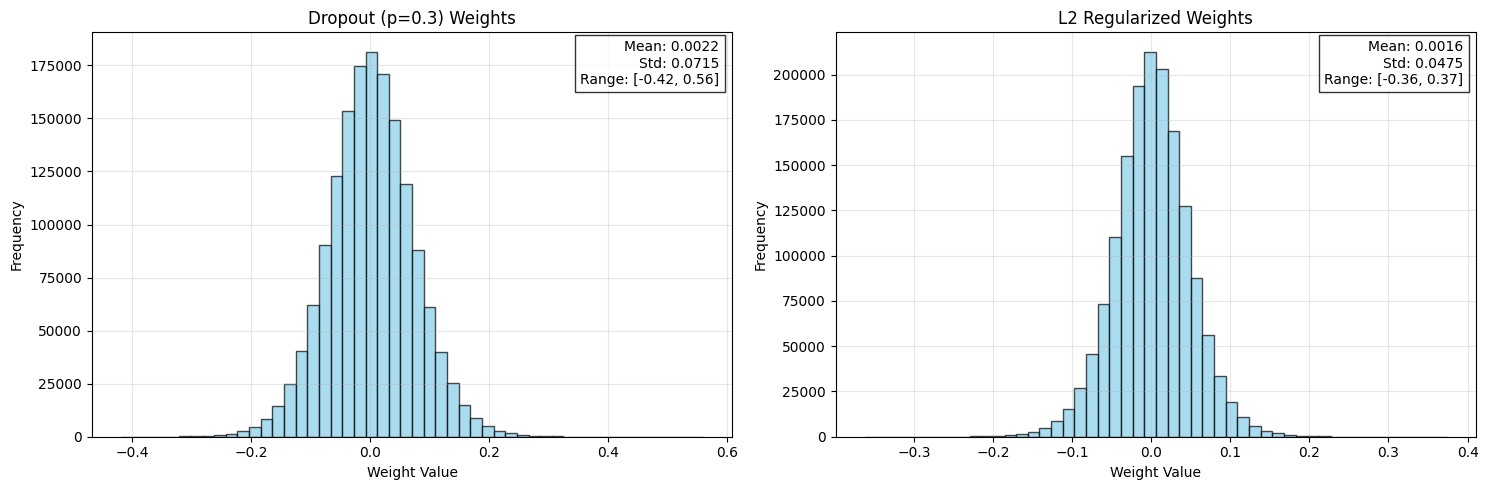

In [ ]:
def plot_weights_comparison(*models):
    plt.figure(figsize=(15, 5))

    for idx, (name, model) in enumerate(models, 1):
        # Get weights from first linear layer
        weights = model.fc1.weight.detach().cpu().numpy().flatten()

        plt.subplot(1, len(models), idx)
        plt.hist(weights, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.title(f'{name} Weights', fontsize=12)
        plt.xlabel('Weight Value', fontsize=10)
        plt.ylabel('Frequency', fontsize=10)

        # Add statistics
        stats = (f"Mean: {weights.mean():.4f}\n"
                f"Std: {weights.std():.4f}\n"
                f"Range: [{weights.min():.2f}, {weights.max():.2f}]")
        plt.text(0.98, 0.98, stats,
                transform=plt.gca().transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8))

        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot weights from your existing models
plot_weights_comparison(
    # ("Base Model", base_model),
    ("Dropout (p=0.3)", dropout_model),
    ("L2 Regularized", l2_model)
)

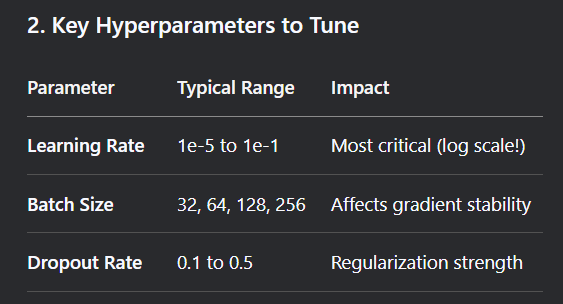

# Hyperparameter Space Search

In [ ]:
from sklearn.model_selection import ParameterGrid

params = {
    'lr': [0.1, 0.01, 0.001],
    'batch_size': [64, 128, 256]
}

for config in ParameterGrid(params):
    train_loader = DataLoader(..., batch_size=config['batch_size'])
    optimizer = optim.SGD(model.parameters(), lr=config['lr'])
    train_model(...)

In [ ]:
from sklearn.model_selection import ParameterSampler

params = {
    'lr': np.logspace(-4, -1, 100),  # 100 values between 0.0001 and 0.1
    'hidden_size': [128, 256, 512]
}

for config in ParameterSampler(params, n_iter=10):  # Try 10 random combos
    model = SimpleMLP(hidden_size=config['hidden_size'])
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    train_model(...)

improvements:

- better use train data

- cross validation, single hold out, etc

- grayscale train data

- experiment with batch size


# Hands on Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [ ]:
# Step 2: Load the California Housing dataset
# This is a real-world dataset containing housing prices in California
housing = fetch_california_housing(as_frame=True)

# Convert to pandas DataFrame for better visualization
df = housing.frame
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("\nDataset description:")
print(df.describe())


Dataset description:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min       

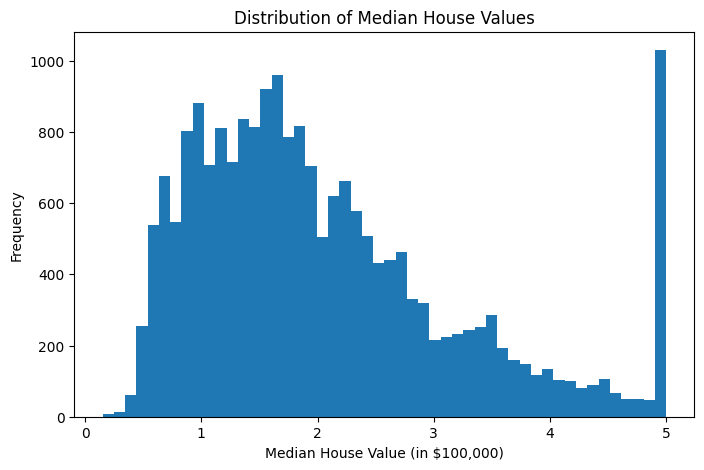

In [ ]:
# Visualize the target variable (median house value)
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value (in $100,000)')
plt.ylabel('Frequency')
plt.show()